# Frontal Alpha Asymmetry (FAA) Step-by-Step Test

This notebook tests the FAA pipeline in `ppg_eeg.eeg` on one existing EEG file in this repo.

Functions tested:
- `preprocess_eeg` (used to band-pass, reject bad channels, re-reference before FAA)
- `_alpha_power_per_channel` (internal helper, sanity-checked indirectly)
- `faa` (fixed alpha band)
- `faa` (individualized alpha band centered on the posterior PAF)
- `frontal_alpha_asymmetry` (convenience wrapper)
- `plot_faa`

Sign convention used throughout: `FAA = ln(P_alpha[right]) - ln(P_alpha[left])`.
Positive FAA -> less alpha on the left -> relatively greater left-frontal activity (approach / positive affect).


In [3]:
%matplotlib inline

from pathlib import Path
import sys
import numpy as np
import mne
import matplotlib.pyplot as plt

# Make imports robust regardless of notebook working directory.
repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ppg_eeg").is_dir():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repo root containing 'ppg_eeg' directory.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo root:", repo_root)

from ppg_eeg.eeg import (
    FRONTAL_PAIRS_DEFAULT,
    preprocess_eeg,
    faa,
    frontal_alpha_asymmetry,
    plot_faa,
)


Using repo root: /Users/sarabonyadian/Documents/HIIT/ppg-eeg


In [5]:
# Choose one EEG file from a non-HIIT dataset (prefer ds006848)
raw_data_dir = repo_root / "data" / "raw"
preferred_dataset_dir = raw_data_dir / "ds006848"

if preferred_dataset_dir.is_dir():
    candidate_files = sorted(preferred_dataset_dir.rglob("*.vhdr"))
    dataset_used = preferred_dataset_dir.name
else:
    # Fallback: any non-HIIT folder under data/raw
    candidate_files = []
    dataset_used = None
    for d in sorted(raw_data_dir.iterdir()):
        if d.is_dir() and d.name.lower() != "hiit":
            files = sorted(d.rglob("*.vhdr"))
            if files:
                candidate_files = files
                dataset_used = d.name
                break

if not candidate_files:
    raise FileNotFoundError(
        f"No BrainVision .vhdr file found in non-HIIT datasets under {raw_data_dir}"
    )

# Prefer rest recordings when available in ds006848, otherwise first file.
rest_files = [p for p in candidate_files if "task-rest" in p.name]
eeg_vhdr_path = rest_files[0] if rest_files else candidate_files[0]

print("Dataset used:", dataset_used)
print("Selected EEG file:", eeg_vhdr_path)


Dataset used: ds006848
Selected EEG file: /Users/sarabonyadian/Documents/HIIT/ppg-eeg/data/raw/ds006848/sub-001/eeg/sub-001_task-rest_eeg.vhdr


In [6]:
# Load EEG, keep EEG channels only
raw = mne.io.read_raw_brainvision(eeg_vhdr_path, preload=True, verbose="ERROR")
raw.pick_types(eeg=True)

print(raw)
print("Sampling frequency:", raw.info["sfreq"])
print("Number of EEG channels:", len(raw.ch_names))


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<RawBrainVision | sub-001_task-rest_eeg.eeg, 64 x 732280 (732.3 s), ~357.6 MiB, data loaded>
Sampling frequency: 1000.0
Number of EEG channels: 64


In [7]:
# Step 0: preprocess (band-pass, drop bad channels, common-average reference)
pre = preprocess_eeg(raw)
raw_pp = pre.raw

print("Bad channels dropped:", pre.bad_channels)
print("Remaining channels:", len(raw_pp.ch_names))


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Bad channels dropped: ['ECG']
Remaining channels: 63


In [8]:
# Inspect which default frontal pairs are usable in this file
available = []
missing = []
for L, R in FRONTAL_PAIRS_DEFAULT:
    if L in raw_pp.ch_names and R in raw_pp.ch_names:
        available.append((L, R))
    else:
        missing.append((L, R))

print("Default frontal pairs:", FRONTAL_PAIRS_DEFAULT)
print("Available pairs in this file:", available)
print("Missing pairs in this file:", missing)


Default frontal pairs: [('F3', 'F4'), ('F7', 'F8')]
Available pairs in this file: [('F3', 'F4'), ('F7', 'F8')]
Missing pairs in this file: []


In [9]:
# Step 1: faa with fixed alpha band (8-13 Hz)
res_fixed = faa(
    raw_pp,
    alpha_band=(8.0, 13.0),
    use_individual_alpha=False,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("alpha_band_used:", res_fixed.alpha_band_used)
print("per_pair:")
for k, v in res_fixed.per_pair.items():
    print(f"  {k}: {v:+.4f}" if np.isfinite(v) else f"  {k}: NaN")
print("mean_faa:", res_fixed.mean_faa)
print("missing_pairs:", res_fixed.missing_pairs)


alpha_band_used: (8.0, 13.0)
per_pair:
  F4-F3: -0.0312
  F8-F7: -0.0437
mean_faa: -0.037471912728287426
missing_pairs: []


In [10]:
# Step 2: faa with individualized alpha band (band = [PAF-2, PAF+2])
res_iaf = faa(
    raw_pp,
    use_individual_alpha=True,
    iaf_half_width=2.0,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("alpha_band_used (individualized):", res_iaf.alpha_band_used)
print("per_pair:")
for k, v in res_iaf.per_pair.items():
    print(f"  {k}: {v:+.4f}" if np.isfinite(v) else f"  {k}: NaN")
print("mean_faa:", res_iaf.mean_faa)
print("missing_pairs:", res_iaf.missing_pairs)


alpha_band_used (individualized): (8.7421875, 12.7421875)
per_pair:
  F4-F3: -0.0302
  F8-F7: -0.0332
mean_faa: -0.031712511058087145
missing_pairs: []


In [11]:
# Step 3: frontal_alpha_asymmetry convenience wrapper -> mean_faa only
mean_only = frontal_alpha_asymmetry(raw_pp)
print("frontal_alpha_asymmetry (mean only):", mean_only)
print("matches faa(...).mean_faa:", np.isclose(mean_only, res_fixed.mean_faa))


frontal_alpha_asymmetry (mean only): -0.037471912728287426
matches faa(...).mean_faa: True


plot_faa -> mean_faa: -0.037471912728287426
plot_faa -> alpha_band_used: (8.0, 13.0)
plot_faa -> per_pair: {'F4-F3': -0.031229139873648837, 'F8-F7': -0.043714685582926016}


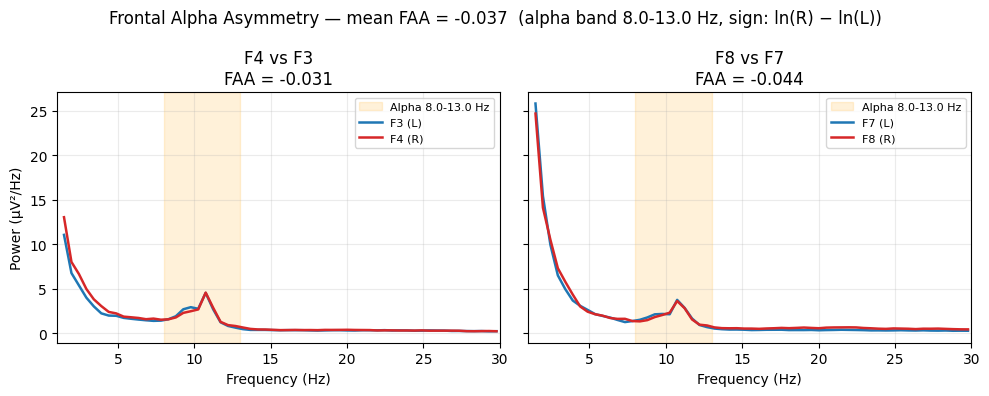

In [12]:
# Step 4: plot_faa (one subplot per pair, alpha band shaded, FAA annotated)
plot_result = plot_faa(
    raw_pp,
    alpha_band=(8.0, 13.0),
    use_individual_alpha=False,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("plot_faa -> mean_faa:", plot_result.result.mean_faa)
print("plot_faa -> alpha_band_used:", plot_result.result.alpha_band_used)
print("plot_faa -> per_pair:", plot_result.result.per_pair)
plt.show()


plot_faa (IAF) -> mean_faa: -0.031712511058087145
plot_faa (IAF) -> alpha_band_used: (8.7421875, 12.7421875)
plot_faa (IAF) -> per_pair: {'F4-F3': -0.03019671298004889, 'F8-F7': -0.0332283091361254}


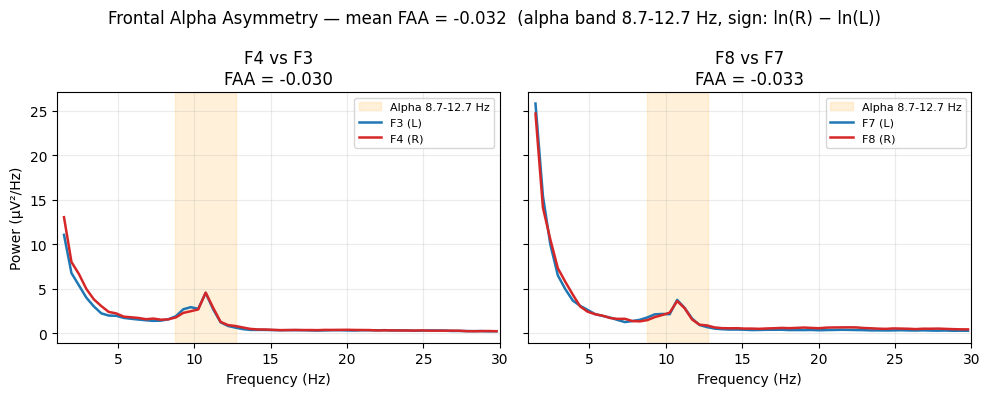

In [13]:
# Step 5: plot_faa with individualized alpha band
plot_result_iaf = plot_faa(
    raw_pp,
    use_individual_alpha=True,
    iaf_half_width=2.0,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("plot_faa (IAF) -> mean_faa:", plot_result_iaf.result.mean_faa)
print("plot_faa (IAF) -> alpha_band_used:", plot_result_iaf.result.alpha_band_used)
print("plot_faa (IAF) -> per_pair:", plot_result_iaf.result.per_pair)
plt.show()
